Leveraged Cointegration Pairs Trading
=====================================

This tutorial demonstrates a portfolio-level pairs trading strategy with
`PortfolioBacktest`.

The strategy trades two assets in one shared account. It estimates a rolling
hedge ratio, builds a spread, enters when the spread z-score is far from zero,
and exits when the spread mean reverts. The account uses margin, so the pair
can run with gross exposure greater than cash.

The example is self-contained. It uses bundled `GOOG` sample data and creates
a synthetic cointegrated peer so the notebook can run without downloading
market data. In real research, pair discovery and statistical validation should
happen before this backtest.

## Imports

`PortfolioBacktest` is the important class here. Unlike
`backtesting.lib.MultiBacktest`, it runs one strategy across multiple symbols
with shared cash, margin, open orders, trades, and portfolio equity.

In [1]:
from pathlib import Path
import tempfile

import numpy as np
import pandas as pd

from backtesting import PortfolioBacktest, Strategy
from backtesting.test import GOOG

/home/ubuntu/projects/backtesting.py/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

## Prepare A Cointegrated Pair

`PortfolioBacktest` expects a mapping of symbol names to OHLCV dataframes.
All assets are aligned to a common index before trading starts.

The helper below creates a peer whose close is a noisy linear function of
`GOOG`. The same positive ratio is applied to all OHLC prices on each bar, so
every synthetic candle keeps valid OHLC relationships.

<Axes: title={'center': 'Normalized close prices'}>

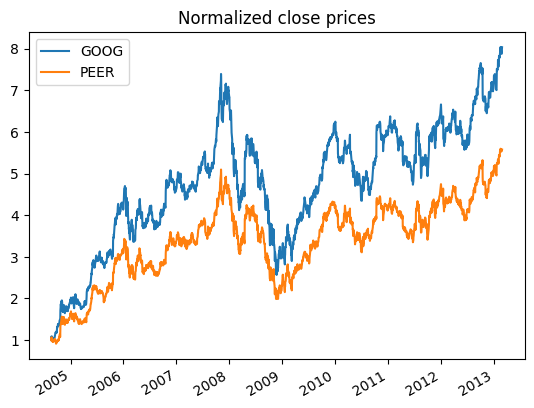

In [2]:
def make_cointegrated_peer(base, *, seed=7):
    rng = np.random.default_rng(seed)
    eps = np.zeros(len(base))
    for i in range(1, len(eps)):
        eps[i] = 0.95 * eps[i - 1] + rng.normal(0, 3)

    peer_close = 40 + 0.72 * base.Close.to_numpy() + eps
    ratio = peer_close / base.Close.to_numpy()

    peer = base[["Open", "High", "Low", "Close"]].mul(ratio, axis=0)
    peer["Volume"] = base.Volume * 1.1
    return peer


data = {
    "GOOG": GOOG,
    "PEER": make_cointegrated_peer(GOOG),
}

normalized_closes = pd.DataFrame(
    {symbol: frame.Close / frame.Close.iloc[0] for symbol, frame in data.items()}
)
normalized_closes.plot(title="Normalized close prices")

## Rolling Hedge Ratio And Spread

The indicator function is causal. For each bar, the rolling regression uses
the current completed close and previous closes only. With the default
execution model, orders placed from those signals fill no earlier than the next
bar open.

This is a rolling hedge-ratio model, not a full pair selection pipeline. If you
are testing real symbols, perform out-of-sample pair selection and
cointegration checks separately before placing the pair into this strategy.

In [3]:
def rolling_pair_state(y, x, lookback):
    y = pd.Series(y)
    x = pd.Series(x)

    beta = y.rolling(lookback).cov(x) / x.rolling(lookback).var()
    alpha = y.rolling(lookback).mean() - beta * x.rolling(lookback).mean()

    spread = y - (alpha + beta * x)
    zscore = (spread - spread.rolling(lookback).mean()) / spread.rolling(lookback).std()

    return beta, spread, zscore

## Define The Portfolio Strategy

In a portfolio strategy:

* `self.data[symbol]` gives per-symbol OHLCV arrays;
* `self.buy(symbol, ...)` and `self.sell(symbol, ...)` place symbol-specific
  orders;
* `self.position[symbol]` inspects or closes one symbol's position;
* `self.equity` is portfolio-level cash plus mark-to-market P/L.

The pair is sized in whole units. `gross_leverage=1.5` means the desired gross
notional is roughly 150% of current equity. The account itself is configured
later with `margin=1 / 2`, or 2:1 maximum leverage, leaving a buffer for
commissions and adverse fills.

In [4]:
class CointegrationPair(Strategy):
    y_symbol = "GOOG"
    x_symbol = "PEER"

    lookback = 60
    entry_z = 2.0
    exit_z = 0.5
    stop_z = 4.0
    gross_leverage = 1.5

    min_beta = 0.05
    max_beta = 10.0

    def init(self):
        self.beta, self.spread, self.zscore = self.I(
            rolling_pair_state,
            self.data[self.y_symbol].Close,
            self.data[self.x_symbol].Close,
            self.lookback,
            name=("hedge beta", "spread", "spread zscore"),
        )

    def _close_pair(self):
        self.position[self.y_symbol].close()
        self.position[self.x_symbol].close()

    def _pair_units(self):
        beta = float(self.beta[-1])
        y_price = float(self.data[self.y_symbol].Close[-1])
        x_price = float(self.data[self.x_symbol].Close[-1])

        if not np.isfinite(beta) or not self.min_beta <= beta <= self.max_beta:
            return 0, 0

        gross_notional = self.equity * self.gross_leverage
        y_units = int(gross_notional // (y_price + beta * x_price))
        x_units = int(round(beta * y_units))

        return y_units, x_units

    def next(self):
        zscore = float(self.zscore[-1])
        if not np.isfinite(zscore):
            return

        y_position = self.position[self.y_symbol]
        x_position = self.position[self.x_symbol]
        in_pair = bool(y_position) or bool(x_position)

        # If one leg failed to open or was otherwise closed, flatten the other.
        if bool(y_position) != bool(x_position):
            self._close_pair()
            return

        if in_pair:
            if abs(zscore) < self.exit_z or abs(zscore) > self.stop_z:
                self._close_pair()
            return

        y_units, x_units = self._pair_units()
        if y_units < 1 or x_units < 1:
            return

        if zscore > self.entry_z:
            # Spread is high: short y, long beta units of x.
            self.sell(self.y_symbol, size=y_units, tag="spread_high")
            self.buy(self.x_symbol, size=x_units, tag="spread_high")

        elif zscore < -self.entry_z:
            # Spread is low: long y, short beta units of x.
            self.buy(self.y_symbol, size=y_units, tag="spread_low")
            self.sell(self.x_symbol, size=x_units, tag="spread_low")

## Run The Backtest

This is one portfolio-level simulation. Both legs compete for the same cash
and margin, and the equity curve includes mark-to-market P/L from both symbols.

In [5]:
bt = PortfolioBacktest(
    data,
    CointegrationPair,
    cash=100_000,
    commission=0.001,
    margin=1 / 2,
    finalize_trades=True,
)

stats = bt.run()
stats

PortfolioBacktest.run:   0%|          | 0/2029 [00:00<?, ?bar/s]

Start                     2005-02-07 00:00:00
End                       2013-03-01 00:00:00
Duration                   2944 days 00:00:00
Exposure Time [%]                    22.70936
Equity Final [$]                 142566.75907
Equity Peak [$]                  144741.35403
Commissions [$]                   15022.32512
Return [%]                           42.56676
Buy & Hold Return [%]                286.4469
Return (Ann.) [%]                     4.50077
Volatility (Ann.) [%]                 5.68592
CAGR [%]                              3.08219
Sharpe Ratio                          0.79157
Sortino Ratio                         1.30673
Calmar Ratio                          0.72785
Alpha [%]                            41.55446
Beta                                  0.00353
Max. Drawdown [%]                    -6.18367
Avg. Drawdown [%]                    -1.29623
Max. Drawdown Duration      326 days 00:00:00
Avg. Drawdown Duration       48 days 00:00:00
# Trades                          

## Inspect Trades

The trades dataframe includes a `Symbol` column. A pair entry produces one
trade in each leg, linked here by the shared `Tag`.

In [6]:
trades = stats["_trades"]
trades.head()

,Symbol,Size,EntryBar,ExitBar,EntryPrice,ExitPrice,SL,TP,PnL,Commission,...,EntryTime,ExitTime,Duration,Tag,Entry_hedge beta,Exit_hedge beta,Entry_spread,Exit_spread,Entry_spread zscore,Exit_spread zscore
0,PEER,434,126,134,170.441952,156.928389,None,None,-6006.965091,142.078728,...,2005-02-17,2005-03-02,13 days,spread_high,1.107320,0.818913,10.512077,7.366055,1.804148,0.780889
1,GOOG,-386,126,134,197.830000,185.950000,None,None,4437.540920,148.139080,...,2005-02-17,2005-03-02,13 days,spread_high,1.107320,0.818913,10.512077,7.366055,1.804148,0.780889
2,PEER,-340,142,157,161.123673,161.175760,None,None,-127.291391,109.581807,...,2005-03-14,2005-04-05,22 days,spread_low,0.669246,0.891603,-7.307382,4.634168,-2.076953,0.338128
3,GOOG,521,142,157,178.330000,187.730000,None,None,4706.682740,190.717260,...,2005-03-14,2005-04-05,22 days,spread_low,0.669246,0.891603,-7.307382,4.634168,-2.076953,0.338128
4,PEER,-407,189,192,210.123583,219.867517,None,None,-4140.787739,175.006378,...,2005-05-19,2005-05-24,5 days,spread_low,1.366698,1.340119,-10.654174,-5.633126,-2.062499,-1.077113


In [7]:
trades.groupby("Symbol").agg(
    Trades=("PnL", "size"),
    TotalPnL=("PnL", "sum"),
    AvgPnL=("PnL", "mean"),
    AvgReturnPct=("ReturnPct", "mean"),
    WinRate=("PnL", lambda s: (s > 0).mean()),
)

,Trades,TotalPnL,AvgPnL,AvgReturnPct,WinRate
Symbol,,,,,
GOOG,42,-6528.412980,-155.438404,-0.001563,0.523810
PEER,42,49095.172049,1168.932668,0.011048,0.571429


## Compare Against GOOG Buy And Hold

The strategy begins after rolling-indicator warmup. For a fair comparison, the
benchmark below uses GOOG close-to-close performance over the same effective
equity-curve window.

The Sharpe helper follows the same annualized-return and annualized-volatility
convention used by `backtesting.py` statistics.

In [8]:
def geometric_mean(returns):
    returns = returns.fillna(0) + 1
    if np.any(returns <= 0):
        return 0
    return np.exp(np.log(returns).sum() / len(returns)) - 1


def backtesting_style_sharpe(equity, annual_trading_days=252):
    day_returns = equity.resample("D").last().dropna().pct_change()
    gmean_day_return = geometric_mean(day_returns)

    annualized_return = (1 + gmean_day_return) ** annual_trading_days - 1
    annualized_volatility = np.sqrt(
        (day_returns.var(ddof=1) + (1 + gmean_day_return) ** 2) ** annual_trading_days
        - (1 + gmean_day_return) ** (2 * annual_trading_days)
    )

    return annualized_return / annualized_volatility, annualized_return, annualized_volatility


equity = stats["_equity_curve"]["Equity"]
start, end = equity.index[0], equity.index[-1]

goog_close = GOOG.loc[start:end, "Close"]
goog_buy_hold_equity = 100_000 * goog_close / goog_close.iloc[0]

goog_drawdown = goog_buy_hold_equity / goog_buy_hold_equity.cummax() - 1
goog_sharpe, goog_ann_return, goog_ann_volatility = backtesting_style_sharpe(
    goog_buy_hold_equity
)

comparison = pd.DataFrame(
    {
        "Pairs strategy": {
            "Final Equity [$]": stats["Equity Final [$]"],
            "Return [%]": stats["Return [%]"],
            "Max. Drawdown [%]": stats["Max. Drawdown [%]"],
            "Sharpe Ratio": stats["Sharpe Ratio"],
            "Ann. Return [%]": stats["Return (Ann.) [%]"],
            "Ann. Volatility [%]": stats["Volatility (Ann.) [%]"],
        },
        "GOOG buy and hold": {
            "Final Equity [$]": goog_buy_hold_equity.iloc[-1],
            "Return [%]": (goog_buy_hold_equity.iloc[-1] / 100_000 - 1) * 100,
            "Max. Drawdown [%]": goog_drawdown.min() * 100,
            "Sharpe Ratio": goog_sharpe,
            "Ann. Return [%]": goog_ann_return * 100,
            "Ann. Volatility [%]": goog_ann_volatility * 100,
        },
    }
)

comparison

,Pairs strategy,GOOG buy and hold
Final Equity [$],142566.759069,411258.480845
Return [%],42.566759,311.258481
Max. Drawdown [%],-6.183675,-65.294760
Sharpe Ratio,0.791565,0.474117
Ann. Return [%],4.500775,19.188663
Ann. Volatility [%],5.685918,40.472399


## Save Results

This mirrors the kind of artifact export you may want in research scripts.
The temporary directory contains a scalar stats summary, the full trade ledger,
the portfolio equity curve, per-symbol P/L, the benchmark comparison, and an
HTML plot for GOOG.

In [9]:
outdir = Path(tempfile.mkdtemp(prefix="backtesting_pairs_"))

summary = stats.drop(labels=["_strategy", "_equity_curve", "_trades"])
per_symbol = trades.groupby("Symbol").agg(
    Trades=("PnL", "size"),
    TotalPnL=("PnL", "sum"),
    AvgPnL=("PnL", "mean"),
    AvgReturnPct=("ReturnPct", "mean"),
    WinRate=("PnL", lambda s: (s > 0).mean()),
)

summary.to_csv(outdir / "stats_summary.csv", header=["Value"])
trades.to_csv(outdir / "trades.csv", index=False)
stats["_equity_curve"].to_csv(outdir / "equity_curve.csv")
per_symbol.to_csv(outdir / "per_symbol_pnl.csv")
comparison.to_csv(outdir / "benchmark_comparison.csv")

bt.plot(symbol="GOOG", filename=str(outdir / "plot_GOOG.html"), open_browser=False)

outdir

PosixPath('/tmp/backtesting_pairs_e0a8591r')

## Practical Notes

* `PortfolioBacktest` trades whole units. Use enough cash, scaled instruments,
  or data transformed into smaller units when needed.
* Fractional order sizes like `size=.25` mean a fraction of available buying
  power at order processing time. They are not continuously rebalanced target
  portfolio weights.
* Market orders are filled on the next bar open by default. Use
  `trade_on_close=True` if your research assumptions require same-bar close
  fills.
* The benchmark statistics `Buy & Hold Return [%]`, `Alpha [%]`, and `Beta`
  reported by `PortfolioBacktest` use an equal-weight normalized-symbol
  benchmark. For a specific benchmark like GOOG buy-and-hold, compute it
  explicitly as shown above.